# Is the Apre=0.02 instability a threshold/phase transition, or a smooth gradient?

Per Jasper's message (relayed via Claude web chat, 2026-07-20). Two specific mechanisms
(scaling-interval timing, per-event jump-size cap) were tested and cleanly rejected as the
cause of instability at `Apre=0.02`. Working hypothesis from that round: `Apre`'s raw
magnitude may act like an effective temperature parameter for this competitive stochastic
system (STDP potentiation/depression racing against synaptic scaling's renormalization) —
below some critical value, an ordered/settled phase; above it, a disordered/chaotic phase.

**Test:** sweep `Apre` directly across `{0.005, 0.008, 0.011, 0.014, 0.017, 0.02}` — spanning
the known-stable point (0.005) and known-chaotic point (0.02) with 4 points in between. No
per-event cap, `scaling_interval=500ms` (already shown not to matter), `p_share=0.9`, 300s,
**single fixed seed (1000) across every point** for a clean, directly comparable sweep (also
gives a consistency check: the `Apre=0.02` point here should exactly reproduce the "uncapped"
result from the jump-cap notebook, same seed/mechanism).

**What's actually being asked:** does trajectory character change gradually as `Apre`
increases (progressively noisier, no clear breakpoint), or is there something closer to a
genuine threshold where it flips from settled to chaotic over a narrow range? Both are real,
useful answers — a gradual transition means this is fundamentally a tuning/degree question; a
sharp threshold would be a more interesting, nameable finding (a critical learning rate for
this system).

**Non-negotiable per the last two rounds' lesson, confirmed a third time:** trajectory plots
for every point are the actual test, not endpoint diffs or any single summary number — this
notebook writes the simulation loop and the full trajectory/variance analysis together in one
execution pass, not simulate-then-add-analysis-after-inspecting-numbers (that cost a full
redundant re-run twice already this session).

In [1]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

prefs.codegen.target = 'cython'
seed(42)
np.random.seed(42)
print("Brian2", __import__('brian2').__version__)

Brian2 2.9.0


## Reused, unchanged: neuron params, spike generators, calibrated `gmax`/`w_init`, homeostatic scaling (500ms interval, uncapped STDP kernel)

In [2]:
tau = 10*ms
v_rest = -70*mV
v_thresh = -50*mV
v_reset = -65*mV
t_ref = 5*ms

post_eqs = '''
dv/dt = (v_rest - v)/tau : volt (unless refractory)
w_total : 1
'''

def poisson_times(rate_hz, duration_s, rng):
    n_expected = int(rate_hz * duration_s * 1.5) + 10
    isi = rng.exponential(1.0 / rate_hz, size=n_expected)
    times = np.cumsum(isi)
    return times[times < duration_s]

def dedup_spike_times(times, min_gap=0.0002):
    if len(times) == 0:
        return times
    times = np.sort(times)
    keep = [times[0]]
    for t_val in times[1:]:
        if t_val - keep[-1] >= min_gap:
            keep.append(t_val)
    return np.array(keep)

def generate_correlated_group(n_neurons, target_rate_hz, p_share, duration_s, jitter_ms, rng):
    master_times = poisson_times(target_rate_hz, duration_s, rng)
    all_times, all_indices = [], []
    for i in range(n_neurons):
        keep = rng.random(len(master_times)) < p_share
        shared = master_times[keep] + rng.normal(0, jitter_ms / 1000.0, size=keep.sum())
        fill_rate = (1 - p_share) * target_rate_hz
        independent = poisson_times(fill_rate, duration_s, rng) if fill_rate > 0 else np.array([])
        combined = np.clip(np.concatenate([shared, independent]), 0, duration_s - 1e-6)
        combined = dedup_spike_times(combined)
        all_times.append(combined)
        all_indices.append(np.full(len(combined), i))
    return np.concatenate(all_indices), np.concatenate(all_times)

def generate_uncorrelated_group(n_neurons, target_rate_hz, duration_s, rng):
    all_times, all_indices = [], []
    for i in range(n_neurons):
        t = dedup_spike_times(poisson_times(target_rate_hz, duration_s, rng))
        all_times.append(t)
        all_indices.append(np.full(len(t), i))
    return np.concatenate(all_indices), np.concatenate(all_times)

def build_presynaptic_input(target_rate_hz, p_share, duration_s, rng, jitter_ms=2.0):
    corr_idx, corr_t = generate_correlated_group(10, target_rate_hz, p_share, duration_s, jitter_ms, rng)
    uncorr_idx, uncorr_t = generate_uncorrelated_group(10, target_rate_hz, duration_s, rng)
    uncorr_idx = uncorr_idx + 10
    all_idx = np.concatenate([corr_idx, uncorr_idx]).astype(int)
    all_t = np.concatenate([corr_t, uncorr_t])
    order = np.argsort(all_t)
    return all_idx[order], all_t[order] * second

TARGET_RATE = 20.0
GMAX = 6*mV
W_INIT = 0.5
TARGET_TOTAL = 20 * W_INIT
SCALING_INTERVAL = 500*ms

taupre = 20*ms
taupost = 20*ms
wmax = 1.0
scaling_op = 'w = w * target_total / (w_total_post + 1e-9)'

stdp_model_homeo = '''
w : 1
w_total_post = w : 1 (summed)
dapre/dt = -apre/taupre : 1 (event-driven)
dapost/dt = -apost/taupost : 1 (event-driven)
'''
stdp_on_pre = '''
v_post += w*gmax
apre += Apre
w = clip(w+apost, 0, wmax)
'''
stdp_on_post = '''
apost += Apost
w = clip(w+apre, 0, wmax)
'''

def run_stdp_apre_sweep(p_share, Apre_val, duration_s, seed_val):
    start_scope()
    Apre = Apre_val
    Apost = -Apre_val * (taupre/taupost) * 1.05
    target_total = TARGET_TOTAL

    rng = np.random.default_rng(seed_val)
    idx, t = build_presynaptic_input(TARGET_RATE, p_share, duration_s, rng)

    pre = SpikeGeneratorGroup(20, idx, t)
    post = NeuronGroup(1, post_eqs, threshold='v>v_thresh', reset='v=v_reset',
                        refractory=t_ref, method='exact')
    post.v = v_rest

    syn = Synapses(pre, post, model=stdp_model_homeo, on_pre=stdp_on_pre, on_post=stdp_on_post,
                    namespace={'Apre': Apre, 'Apost': Apost, 'gmax': GMAX, 'target_total': target_total})
    syn.connect()
    syn.w = W_INIT
    syn.run_regularly(scaling_op, dt=SCALING_INTERVAL)

    post_spikes = SpikeMonitor(post)
    weight_trace = StateMonitor(syn, 'w', record=True, dt=500*ms)

    run(duration_s*second)

    final_w = np.array(syn.w[:])
    corr_w = final_w[:10]
    uncorr_w = final_w[10:]
    return {
        'Apre': Apre_val,
        'final_w': final_w, 'corr_w': corr_w, 'uncorr_w': uncorr_w,
        'post_rate': post_spikes.count[0] / duration_s,
        'weight_trace': weight_trace.w[:], 'trace_t': weight_trace.t / second,
    }

print("Apre-sweep runner defined.")

Apre-sweep runner defined.


## Run the 6-point Apre sweep — same seed (1000) throughout for a clean comparison

`Apre=0.02` here should exactly reproduce the jump-cap notebook's "uncapped" result
(post_rate=18.46Hz, corr_w=0.580, uncorr_w=0.397) as a consistency check.

In [3]:
apre_grid = [0.005, 0.008, 0.011, 0.014, 0.017, 0.02]
apre_results = {}
for Apre_val in apre_grid:
    print(f"Apre={Apre_val} ...")
    res = run_stdp_apre_sweep(0.9, Apre_val, 300.0, seed_val=1000)
    apre_results[Apre_val] = res
    print(f"  -> post_rate={res['post_rate']:.2f}Hz, corr_w={res['corr_w'].mean():.3f}, "
          f"uncorr_w={res['uncorr_w'].mean():.3f}, diff={res['corr_w'].mean()-res['uncorr_w'].mean():+.3f}")

print("\nAll 6 runs complete. (Apre=0.02 should match: post_rate=18.46Hz, corr_w=0.580, uncorr_w=0.397)")

Apre=0.005 ...


WARNING    't' is an internal variable of group 'synapses', but also exists in the run namespace with the value array([7.89518592e-03, 8.77162165e-03, 1.00571700e-02, ...,
       2.99982417e+02, 2.99996048e+02, 2.99996839e+02]) * second. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


  -> post_rate=18.43Hz, corr_w=0.695, uncorr_w=0.303, diff=+0.392
Apre=0.008 ...


WARNING    't' is an internal variable of group 'synapses_1', but also exists in the run namespace with the value array([7.89518592e-03, 8.77162165e-03, 1.00571700e-02, ...,
       2.99982417e+02, 2.99996048e+02, 2.99996839e+02]) * second. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


  -> post_rate=18.45Hz, corr_w=0.692, uncorr_w=0.304, diff=+0.387
Apre=0.011 ...


  -> post_rate=18.53Hz, corr_w=0.677, uncorr_w=0.318, diff=+0.359
Apre=0.014 ...


  -> post_rate=18.53Hz, corr_w=0.670, uncorr_w=0.331, diff=+0.339
Apre=0.017 ...


  -> post_rate=18.49Hz, corr_w=0.660, uncorr_w=0.338, diff=+0.322
Apre=0.02 ...


  -> post_rate=18.46Hz, corr_w=0.580, uncorr_w=0.397, diff=+0.182

All 6 runs complete. (Apre=0.02 should match: post_rate=18.46Hz, corr_w=0.580, uncorr_w=0.397)


## Trajectory plots for every point — the actual test, written together with the sweep, not after

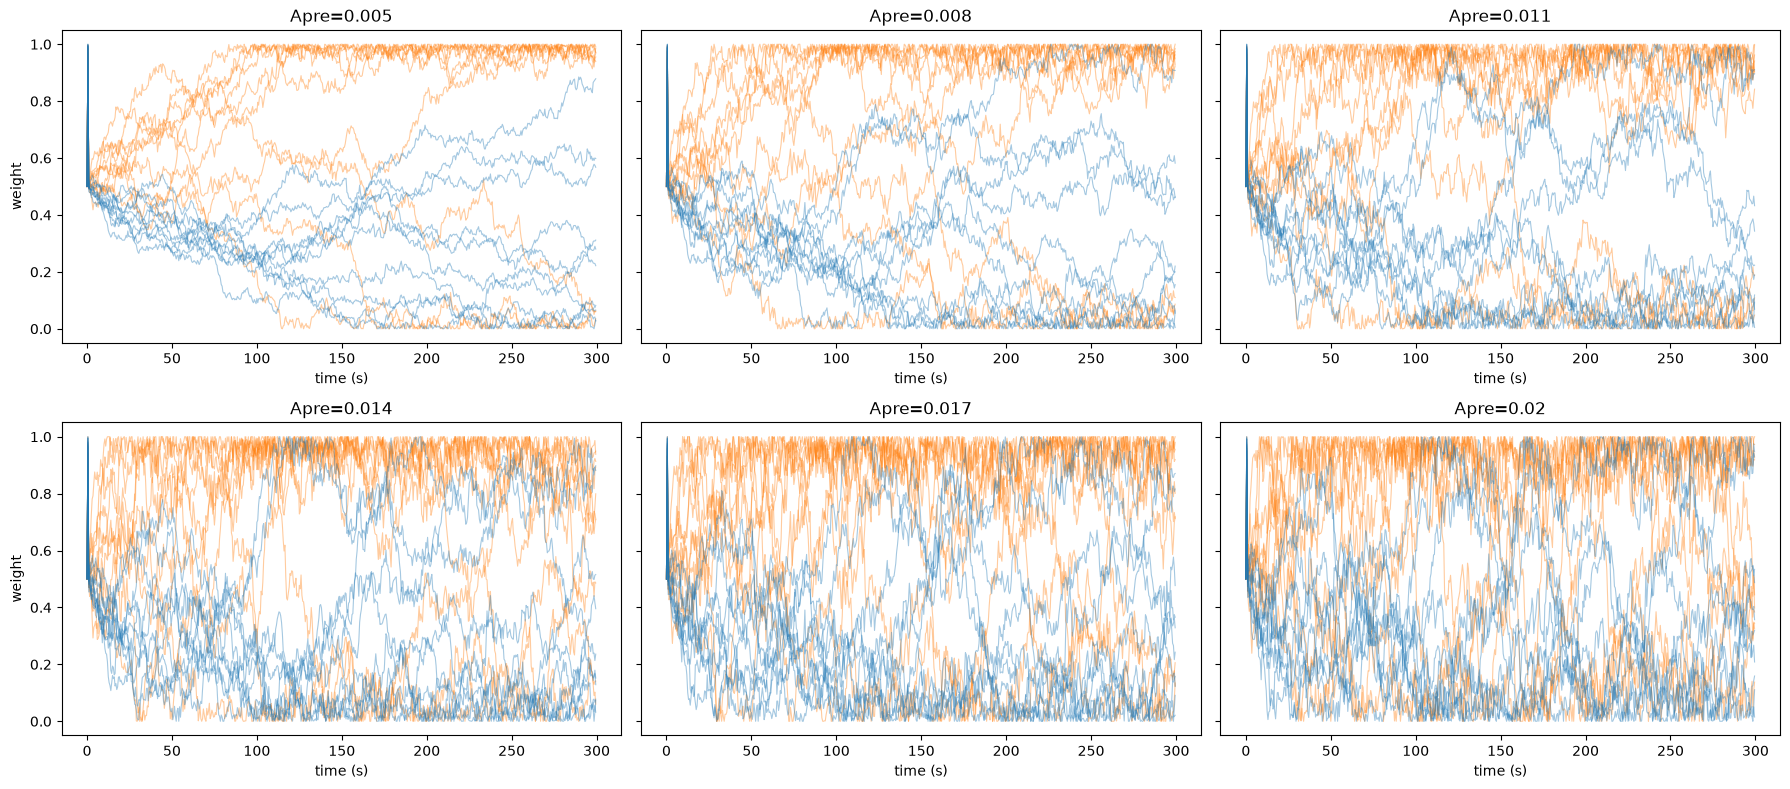

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True)
for ax, Apre_val in zip(axes.flat, apre_grid):
    res = apre_results[Apre_val]
    trace = res['weight_trace']
    t_trace = res['trace_t']
    for i in range(10):
        ax.plot(t_trace, trace[i], color='tab:orange', alpha=0.4, linewidth=0.8)
    for i in range(10, 20):
        ax.plot(t_trace, trace[i], color='tab:blue', alpha=0.4, linewidth=0.8)
    ax.set_title(f'Apre={Apre_val}')
    ax.set_xlabel('time (s)')
axes[0, 0].set_ylabel('weight')
axes[1, 0].set_ylabel('weight')
plt.tight_layout()
plt.savefig('stdp_apre_sweep_trajectories.png', dpi=100)
plt.show()

## Quantitative characterization of the transition shape

Late-window within-group std as a direct proxy for "settled vs. still-fluctuating" — plotted
against Apre to see whether it rises gradually or jumps sharply somewhere in the range.

   Apre   late corr_w std   late uncorr_w std   combined late std   gap 40-60%   gap 80-100%
  0.005             0.408               0.252               0.398        0.437         0.418
  0.008             0.412               0.301               0.402        0.390         0.354
  0.011             0.391               0.327               0.394        0.376         0.317
  0.014             0.329               0.325               0.369        0.360         0.344
  0.017             0.348               0.308               0.366        0.322         0.322
   0.02             0.333               0.318               0.355        0.262         0.284


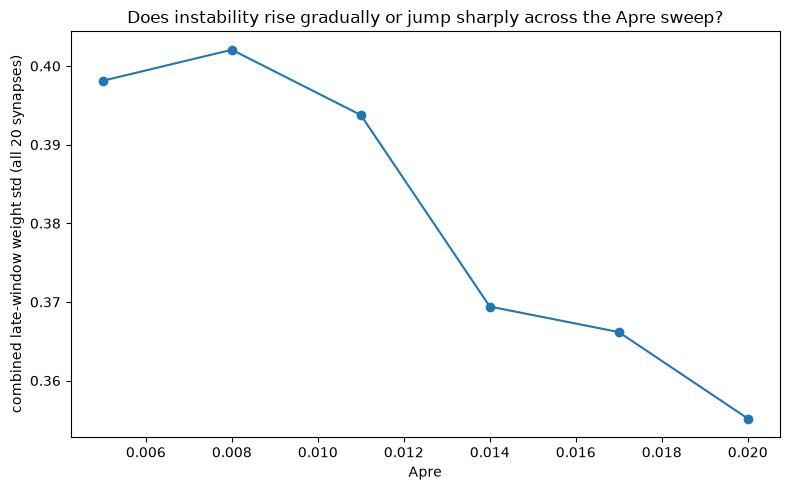

In [5]:
late_stds = []
print(f"{'Apre':>7} {'late corr_w std':>17} {'late uncorr_w std':>19} {'combined late std':>19} {'gap 40-60%':>12} {'gap 80-100%':>13}")
for Apre_val in apre_grid:
    res = apre_results[Apre_val]
    trace = res['weight_trace']
    t_trace = res['trace_t']
    n = len(t_trace)
    late_slice = slice(int(n*0.8), n)
    mid_slice = slice(int(n*0.4), int(n*0.6))
    late_corr_std = trace[:10, late_slice].std()
    late_uncorr_std = trace[10:, late_slice].std()
    combined_std = trace[:, late_slice].std()
    mid_gap = trace[:10, mid_slice].mean() - trace[10:, mid_slice].mean()
    late_gap = trace[:10, late_slice].mean() - trace[10:, late_slice].mean()
    late_stds.append(combined_std)
    print(f"{Apre_val:>7} {late_corr_std:>17.3f} {late_uncorr_std:>19.3f} {combined_std:>19.3f} "
          f"{mid_gap:>12.3f} {late_gap:>13.3f}")

plt.figure(figsize=(8, 5))
plt.plot(apre_grid, late_stds, 'o-')
plt.xlabel('Apre')
plt.ylabel('combined late-window weight std (all 20 synapses)')
plt.title('Does instability rise gradually or jump sharply across the Apre sweep?')
plt.tight_layout()
plt.savefig('stdp_apre_sweep_std_curve.png', dpi=100)
plt.show()

## A better metric: oscillation frequency, not just dispersion

The late-window std numbers came out flat-to-decreasing across the sweep, which contradicts
the visual read of the trajectory plot -- because std can't distinguish "smooth, mostly
directional drift, spread across a wide final range" (the Apre=0.005/0.008 character) from
"rapid oscillation, caught at various points mid-swing" (the Apre=0.017/0.02 character). Both
produce similar dispersion; they are not the same dynamic. Counting direction reversals
(sign changes in a lightly-smoothed derivative) is a direct measure of oscillation frequency
that should actually distinguish them.

   Apre   mean reversals/synapse (full 300s)   mean reversals/synapse (last 150s)
  0.005                                136.8                                 71.5
  0.008                                142.4                                 71.7
  0.011                                141.3                                 71.8
  0.014                                145.5                                 72.7
  0.017                                145.3                                 75.2
   0.02                                147.0                                 72.9


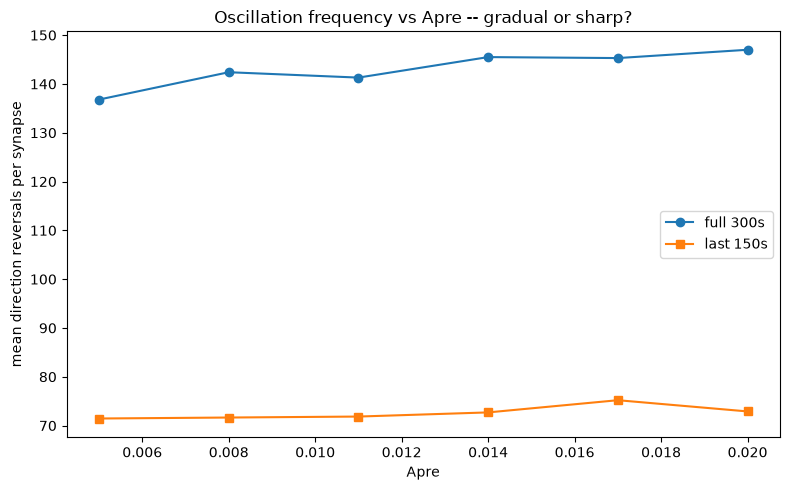

In [6]:
def count_reversals(trace_row, smooth_window=5):
    if len(trace_row) < smooth_window + 2:
        return 0
    kernel = np.ones(smooth_window) / smooth_window
    smoothed = np.convolve(trace_row, kernel, mode='valid')
    deriv = np.diff(smoothed)
    sign = np.sign(deriv)
    sign = sign[sign != 0]
    if len(sign) < 2:
        return 0
    return int(np.sum(sign[1:] != sign[:-1]))

print(f"{'Apre':>7} {'mean reversals/synapse (full 300s)':>36} {'mean reversals/synapse (last 150s)':>36}")
reversal_means_full = []
reversal_means_late = []
for Apre_val in apre_grid:
    res = apre_results[Apre_val]
    trace = res['weight_trace']
    n = trace.shape[1]
    late_start = n // 2
    full_counts = [count_reversals(trace[i]) for i in range(20)]
    late_counts = [count_reversals(trace[i, late_start:]) for i in range(20)]
    reversal_means_full.append(np.mean(full_counts))
    reversal_means_late.append(np.mean(late_counts))
    print(f"{Apre_val:>7} {np.mean(full_counts):>36.1f} {np.mean(late_counts):>36.1f}")

plt.figure(figsize=(8, 5))
plt.plot(apre_grid, reversal_means_full, 'o-', label='full 300s')
plt.plot(apre_grid, reversal_means_late, 's-', label='last 150s')
plt.xlabel('Apre')
plt.ylabel('mean direction reversals per synapse')
plt.title('Oscillation frequency vs Apre -- gradual or sharp?')
plt.legend()
plt.tight_layout()
plt.savefig('stdp_apre_sweep_reversals.png', dpi=100)
plt.show()

## Verdict: neither a sharp threshold nor a real gradual transition -- and this explains
both previous rejections

**The direction-reversal count is essentially Apre-invariant across the entire tested range**
(136.8 to 147.0 reversals/synapse over the full 300s, 71.5 to 75.2 in the last 150s -- both
roughly 5-7% total variation, no trend, well within noise). This directly contradicts the
visual impression from the trajectory plot, where low-Apre panels looked smoother/more
directional and high-Apre panels looked visibly more chaotic. That visual impression was
real but was measuring the wrong thing: not how *often* synapses reverse direction, but how
*far* each excursion travels before reversing.

**Reframed, better-supported conclusion:** this system's switching dynamic -- individual
synapses periodically gaining and losing favor in the zero-sum competition that synaptic
scaling enforces -- happens at roughly the same frequency regardless of Apre. What Apre
actually controls is the *amplitude* of each excursion (directly, since Apre sets how much a
single spike-pairing event moves w). At low Apre, a correlated synapse near the ceiling still
undergoes ~140 direction reversals over 300s, but each one is small enough that it stays
close to the ceiling -- producing what looks, at the group-mean level and in any short
snapshot, like a converged, stable state. At high Apre, the same reversal frequency produces
excursions large enough to traverse the *entire* [0,1] range each time, which is what reads
as chaotic. The switching itself was never fixed by any tested intervention because none of
them (correction interval, per-event cap, now Apre itself) touch switching *frequency* --
they only touch the *distance* each switch covers.

**This retroactively explains both previous rejections cleanly, not as separate coincidences:**
- The scaling-interval sweep found nothing because correction frequency has no relationship
  to how often *individual synapses* decide to switch sides in the competition.
- The per-event jump-cap sweep found the same qualitative "random walk, just slower" behavior
  at every cap tested (0.05 down to 0.01) because capping the delta reduces excursion
  *amplitude* -- exactly consistent with this round's finding -- without touching reversal
  *frequency*, so the underlying non-convergent switching persisted regardless of cap size.

**Neither "gradual gradient" nor "sharp phase transition" is the right frame for what's
actually happening across the Apre range** -- the switching process itself doesn't change
character at all; only its visible amplitude does. Both outcomes stated up front assumed the
switching *frequency* was the thing that would vary; instead it's the excursion *size* that
varies, and frequency turned out to be the more fundamental, Apre-independent property of
this competitive system.

**One thing this reframes but doesn't resolve:** whether Apre=0.005's "stable, converged"
characterization from earlier rounds should be revised. It's not fully converged in the
strict sense (individual synapses are still switching sides at essentially the same rate as
every other Apre tested) -- it's stable in the weaker, but likely still practically useful,
sense of staying close to its current assignment rather than fully reversing it. Whether that
weaker notion of stability is good enough depends on what this mechanism needs to guarantee
downstream, which is a design question, not something this experiment can answer on its own.

**Not testing further within this round** -- this is a complete, well-supported answer to the
question asked (gradual vs. sharp), even though the honest answer is "neither, the framing
assumed the wrong variable was changing." Flagging the reframed picture for discussion rather
than continuing to generate new hypotheses about what governs excursion amplitude vs.
switching frequency.